In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 40  # choose any integer

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
import os
import glob
import numpy as np
import mne
from mne.filter import filter_data

folder = r"D:\EEG DATA\Dataset\dataverse_files"
edf_paths = glob.glob(os.path.join(folder, "*.edf"))

selected_channels = [
    'Fp2','F8','T4','T6','O2','Fp1','F7',
    'T3','T5','O1','F4','C4',
    'P4','F3','C3','P3','Fz','Cz','Pz'
]

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

all_epochs_data = []
labels = []
subject_ids = []   # 🔥 THIS IS IMPORTANT

for edf_file in edf_paths:

    print("Processing:", edf_file)

    # Extract subject name from filename
    subject_name = os.path.basename(edf_file).split(".")[0]

    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    raw.pick_channels([ch for ch in selected_channels if ch in raw.ch_names])

    if raw.info['sfreq'] != 250:
        raw.resample(250)

    raw.filter(0.5, 45, verbose=False)

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=1.0,
        overlap=0.0,
        preload=True,
        verbose=False
    )

    epoch_data = epochs.get_data()   # (n_epochs, 19, 250)

    band_data = []

    for low, high in bands.values():
        filtered = filter_data(
            epoch_data,
            sfreq=250,
            l_freq=low,
            h_freq=high,
            verbose=False
        )
        band_data.append(filtered)

    band_data = np.stack(band_data, axis=1)  
    # (n_epochs, 5, 19, 250)

    all_epochs_data.append(band_data)

    # Assign label
    if "h" in edf_file:
        label = 0
    elif "s" in edf_file:
        label = 1
    else:
        continue

    n_epochs = band_data.shape[0]

    labels.extend([label] * n_epochs)
    subject_ids.extend([subject_name] * n_epochs)  # 🔥 store subject

# Combine everything
X = np.concatenate(all_epochs_data, axis=0)
y = np.array(labels)
groups = np.array(subject_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)



Processing: D:\EEG DATA\Dataset\dataverse_files\h01.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (1651) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (255) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(


Processing: D:\EEG DATA\Dataset\dataverse_files\h02.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (1651) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (255) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(


Processing: D:\EEG DATA\Dataset\dataverse_files\h03.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Processing: D:\EEG DATA\Dataset\dataverse_files\s13.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (1651) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (255) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(


Processing: D:\EEG DATA\Dataset\dataverse_files\s14.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (1651) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (413) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(
C:\Users\Manisha\AppData\Local\Temp\ipykernel_37992\1283395279.py:56: RuntimeWarning: filter_length (255) is longer than the signal (250), distortion is likely. Reduce filter length or filter a longer signal.
  filtered = filter_data(


X shape: (28863, 5, 19, 250)
y shape: (28863,)
groups shape: (28863,)


In [3]:
import os
import glob
import numpy as np
import mne

folder = r"D:\EEG DATA\Dataset\dataverse_files"
edf_paths = glob.glob(os.path.join(folder, "*.edf"))

selected_channels = [
    'Fp2','F8','T4','T6','O2','Fp1','F7',
    'T3','T5','O1','F4','C4',
    'P4','F3','C3','P3','Fz','Cz','Pz'
]

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45)
}

all_epochs_data = []
labels = []
subject_ids = []

for edf_file in edf_paths:

    print("Processing:", edf_file)
    subject_name = os.path.basename(edf_file).split(".")[0]

    raw = mne.io.read_raw_edf(edf_file, preload=True, verbose=False)
    raw.pick_channels([ch for ch in selected_channels if ch in raw.ch_names])

    if raw.info['sfreq'] != 250:
        raw.resample(250)

    raw.filter(0.5, 45, verbose=False)

    epochs = mne.make_fixed_length_epochs(
        raw,
        duration=1.0,
        overlap=0.0,
        preload=True,
        verbose=False
    )

    epoch_data = epochs.get_data()  # (n_epochs, 19, 250)
    sfreq = 250

    n_epochs = epoch_data.shape[0]
    n_channels = epoch_data.shape[1]

    # 🔥 Compute PSD using Welch
    psds, freqs = mne.time_frequency.psd_array_welch(
        epoch_data,
        sfreq=sfreq,
        fmin=0.5,
        fmax=45,
        n_fft=250,
        verbose=False
    )
    # psds shape → (n_epochs, 19, n_freqs)

    # 🔥 Compute band power
    band_power_epochs = np.zeros((n_epochs, n_channels, len(bands)))

    for i, (band_name, (fmin, fmax)) in enumerate(bands.items()):
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, :, freq_mask].mean(axis=2)
        band_power_epochs[:, :, i] = band_power

    # Now shape: (n_epochs, 19, 5)
    all_epochs_data.append(band_power_epochs)

    # Assign label
    if "h" in edf_file.lower():
        label = 0
    elif "s" in edf_file.lower():
        label = 1
    else:
        continue

    labels.extend([label] * n_epochs)
    subject_ids.extend([subject_name] * n_epochs)

# Combine all subjects
X = np.concatenate(all_epochs_data, axis=0)   # (total_epochs, 19, 5)
y = np.array(labels)
groups = np.array(subject_ids)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)

Processing: D:\EEG DATA\Dataset\dataverse_files\h01.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h02.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h03.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h04.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h05.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h06.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\h07.edf
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Processing: D:\EEG DATA\Dataset\dataverse_files\

In [4]:
groups

array(['h01', 'h01', 'h01', ..., 's14', 's14', 's14'], dtype='<U3')

In [5]:
X.shape

(28863, 19, 5)

In [6]:
import numpy as np

X = X          # shape (N, ...)
y = y         # shape (N,)
N = len(y)

rng = np.random.default_rng(seed=42)

train_idx = []
val_idx   = []
test_idx  = []

for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    rng.shuffle(cls_idx)

    n_cls   = len(cls_idx)
    n_train = int(0.70 * n_cls)
    n_val   = int(0.20 * n_cls)

    train_idx.extend(cls_idx[:n_train])
    val_idx.extend(cls_idx[n_train:n_train + n_val])
    test_idx.extend(cls_idx[n_train + n_val:])

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]


In [7]:
from sklearn.model_selection import GroupShuffleSplit

# First split train+val vs test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(X, y, groups))

# Now split train vs val from train_val
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss2.split(X[train_val_idx],
                                     y[train_val_idx],
                                     groups[train_val_idx]))

# Convert back to original indices
train_idx = train_val_idx[train_idx]
val_idx   = train_val_idx[val_idx]


In [8]:
X_train = X[train_idx]
y_train = y[train_idx]

X_val = X[val_idx]
y_val = y[val_idx]

X_test = X[test_idx]
y_test = y[test_idx]


In [9]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(18290, 19, 5) (18290,)
(4665, 19, 5) (4665,)
(5908, 19, 5) (5908,)


In [10]:
# Compute mean & std from training set only
mean = X_train.mean(axis=(0), keepdims=True)
std  = X_train.std(axis=(0), keepdims=True)

# Apply normalization
X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)

In [12]:
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

In [13]:
train_groups = set(groups[train_idx])
val_groups   = set(groups[val_idx])
test_groups  = set(groups[test_idx])

print("Train ∩ Val:", train_groups.intersection(val_groups))
print("Train ∩ Test:", train_groups.intersection(test_groups))
print("Val ∩ Test:", val_groups.intersection(test_groups))


Train ∩ Val: set()
Train ∩ Test: set()
Val ∩ Test: set()


In [14]:
import numpy as np

train_groups = np.unique(groups[train_idx])
val_groups   = np.unique(groups[val_idx])
test_groups  = np.unique(groups[test_idx])

print("Train groups:", train_groups)
print("Val groups:", val_groups)
print("Test groups:", test_groups)


Train groups: ['h04' 'h05' 'h06' 'h07' 'h08' 'h11' 'h14' 's01' 's02' 's03' 's05' 's07'
 's09' 's10' 's11' 's13' 's14']
Val groups: ['h02' 'h03' 'h12' 's04' 's06']
Test groups: ['h01' 'h09' 'h10' 'h13' 's08' 's12']


In [15]:
print("Number of train subjects:", len(train_groups))
print("Number of val subjects:", len(val_groups))
print("Number of test subjects:", len(test_groups))


Number of train subjects: 17
Number of val subjects: 5
Number of test subjects: 6


In [16]:
import pandas as pd

def summarize_split(name, idx):
    df = pd.DataFrame({
        "group": groups[idx],
        "label": y[idx]
    })
    
    summary = df.groupby("group").agg(
        n_epochs=("group", "count"),
        label=("label", "first")
    )
    
    print(f"\n{name} SPLIT")
    print("Subjects:", len(summary))
    print("Healthy subjects:", sum(summary["label"] == 0))
    print("Schizo subjects:", sum(summary["label"] == 1))
    print(summary)

summarize_split("TRAIN", train_idx)
summarize_split("VAL", val_idx)
summarize_split("TEST", test_idx)



TRAIN SPLIT
Subjects: 17
Healthy subjects: 7
Schizo subjects: 10
       n_epochs  label
group                 
h04         925      0
h05         945      0
h06         930      0
h07         910      0
h08         910      0
h11         915      0
h14         865      0
s01         845      1
s02        1145      1
s03         964      1
s05         890      1
s07        1346      1
s09        1185      1
s10         850      1
s11        1360      1
s13        1135      1
s14        2170      1

VAL SPLIT
Subjects: 5
Healthy subjects: 3
Schizo subjects: 2
       n_epochs  label
group                 
h02         910      0
h03         910      0
h12         900      0
s04        1205      1
s06         740      1

TEST SPLIT
Subjects: 6
Healthy subjects: 4
Schizo subjects: 2
       n_epochs  label
group                 
h01         925      0
h09         905      0
h10        1115      0
h13         965      0
s08         911      1
s12        1087      1


In [17]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.layers import BatchNormalization

model_1d = Sequential()

model_1d.add(Conv1D(16, kernel_size=3, activation='relu', input_shape=(19, 5)))
model_1d.add(BatchNormalization())
model_1d.add(MaxPooling1D(pool_size=2))

model_1d.add(Conv1D(32, kernel_size=3, activation='relu'))
model_1d.add(MaxPooling1D(pool_size=2))

model_1d.add(Flatten())
model_1d.add(Dense(32, activation='relu'))
model_1d.add(Dropout(0.5))
model_1d.add(Dense(2, activation='softmax'))

from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)   # change value here

model_1d.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_1d.summary()

f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 17, 16)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 17, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 8, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,058 (19.76 KB)

 Trainable params: 5,026 (19.63 KB)

 Non-trainable params: 32 (128.00 B)

In [18]:

# Model training
history = model_1d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)


Epoch 1/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6510 - loss: 0.6477 - val_accuracy: 0.4161 - val_loss: 1.1147
Epoch 2/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6858 - loss: 0.5736 - val_accuracy: 0.4163 - val_loss: 3.6461
Epoch 3/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7659 - loss: 0.4752 - val_accuracy: 0.4163 - val_loss: 4.0840
Epoch 4/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7925 - loss: 0.4319 - val_accuracy: 0.4165 - val_loss: 4.0246
Epoch 5/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8108 - loss: 0.4061 - val_accuracy: 0.4169 - val_loss: 2.8474
Epoch 6/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8208 - loss: 0.3881 - val_accuracy: 0.4163 - val_loss: 4.7127
Epoch 7/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8279 - loss: 0.3904 - val_accuracy: 0.4309 - val_loss: 1.9056
Epoch 8/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8299 - loss: 0.3720 - val_accuracy: 0.

In [19]:
model_1d.save(r"D:\EEG DATA\eeg_model_1d.h5")

In [20]:
model_1d.evaluate(X_test, y_test)

185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6464 - loss: 2.2308


[2.230848550796509, 0.646411657333374]

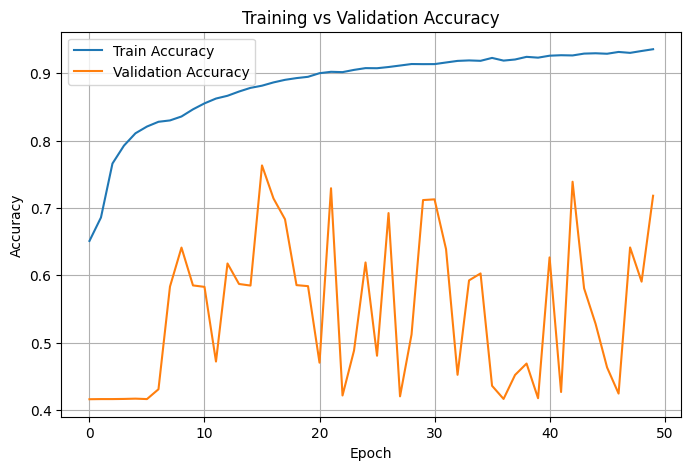

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()


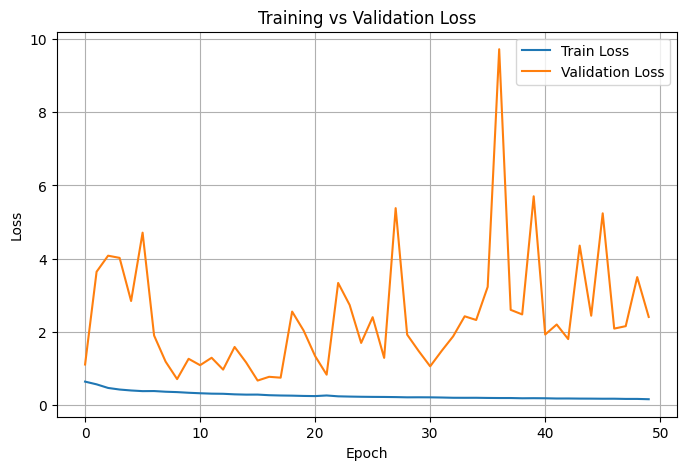

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


In [23]:
import numpy as np

# Train probabilities
y_train_prob = model_1d.predict(X_train)[:, 1]

# Test probabilities
y_test_prob = model_1d.predict(X_test)[:, 1]



572/572 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [24]:
from sklearn.metrics import roc_curve, auc

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
auc_train = auc(fpr_train, tpr_train)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)



Train AUC: 0.9145096588519765
Test AUC: 0.6846373867473611


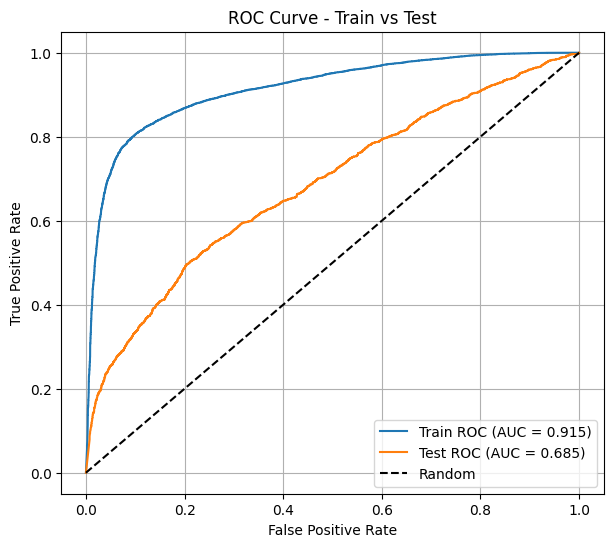

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Train vs Test')
plt.legend()
plt.grid(True)

plt.show()



In [26]:
# predicted class probabilities from softmax
y_prob_all = model_1d.predict(X_test)          # shape (n_samples, 2)

# choose prob for class 1 (seizure)
y_prob = y_prob_all[:, 1]

# class predictions
y_pred = np.argmax(y_prob_all, axis=1)      # 0 or 1

185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score
)

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
sens  = recall_score(y_test, y_pred)        # sensitivity = recall for positive class
cm    = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)                      # specificity
f1    = f1_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)
err   = 1 - acc

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Sensitivity (Recall):", sens)
print("Specificity:", spec)
print("F1-score:", f1)
print("Kappa:", kappa)
print("AUC:", auc)
print("Confusion matrix:\n", cm)


Accuracy: 0.646411645226811
Error: 0.35358835477318895
Precision: 0.4816310052482842
Sensitivity (Recall): 0.5970970970970971
Specificity: 0.6716112531969309
F1-score: 0.5331843575418994
Kappa: 0.25382969790948207
AUC: 0.6846373867473611
Confusion matrix:
 [[2626 1284]
 [ 805 1193]]


#############   SHAP Explainer             #############

In [32]:
y_test[5900:5908]

array([1, 1, 1, 1, 1, 1, 1, 1])

##########         MEAN SHAP VALUES FOR Class 1  ############

In [33]:
import shap
import numpy as np

# Take small random background set
background = X_train[np.random.choice(X_train.shape[0], 1000, replace=False)]

# 2) build explainer
explainer = shap.DeepExplainer(model_1d, background)

# 3) get SHAP values for some test samples
X_sample = X_test[5900:5908]     # (100, 19, 33, 6, 1)
shap_values = explainer.shap_values(X_sample)  # list; for binary: len=1
sh = shap_values

f:\Anaconda\envs\new_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
f:\Anaconda\envs\new_env\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1000, 19, 5))']
  warnings.warn(msg)
f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(2000, 19, 5

In [34]:
shap_values.shape
sh.shape

(8, 19, 5, 2)

In [35]:
shap_class1 = shap_values[:, :, :, 1]
shap_class0 = shap_values[:, :, :, 0]

print(shap_class1.shape)

(8, 19, 5)


In [36]:
mean_shap = np.mean(shap_class1, axis=0)   # (19, 5)

mean_shap.shape

(19, 5)

############      Electrode-wise Band Explanation (Like Fp1, Fp2 blocks)          #########

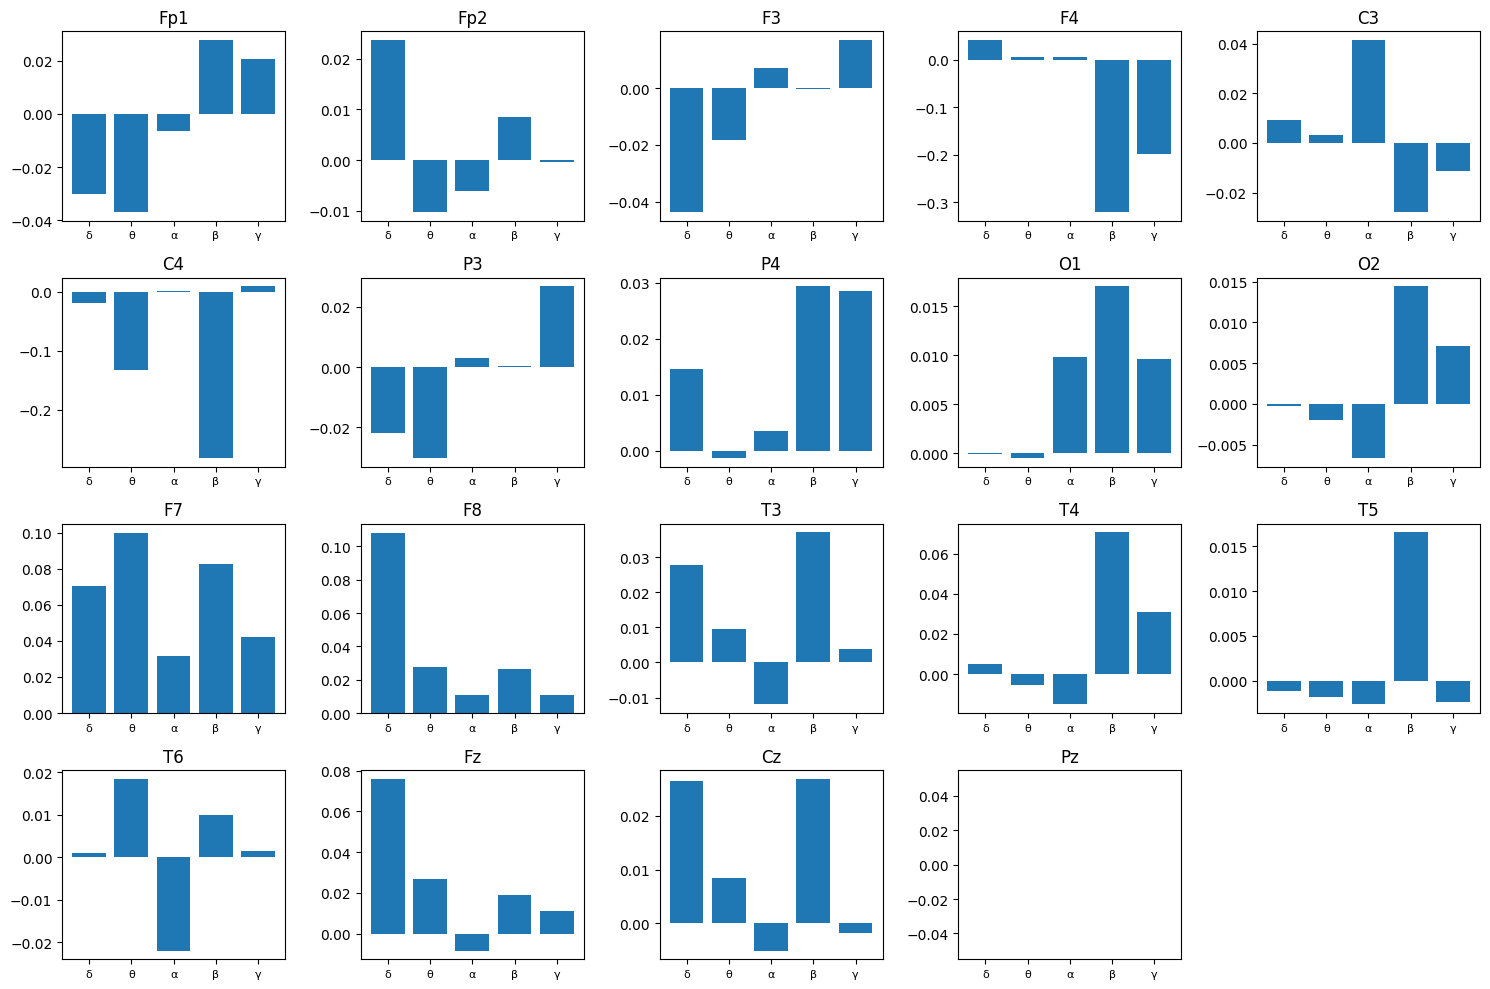

In [37]:
import matplotlib.pyplot as plt
import numpy as np

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].bar(range(5), mean_shap[i])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].tick_params(axis='x', labelsize=8)
axes[19].axis('off')
plt.tight_layout()
plt.show()

#############    Mini Heatmap Per Electrode          ###############

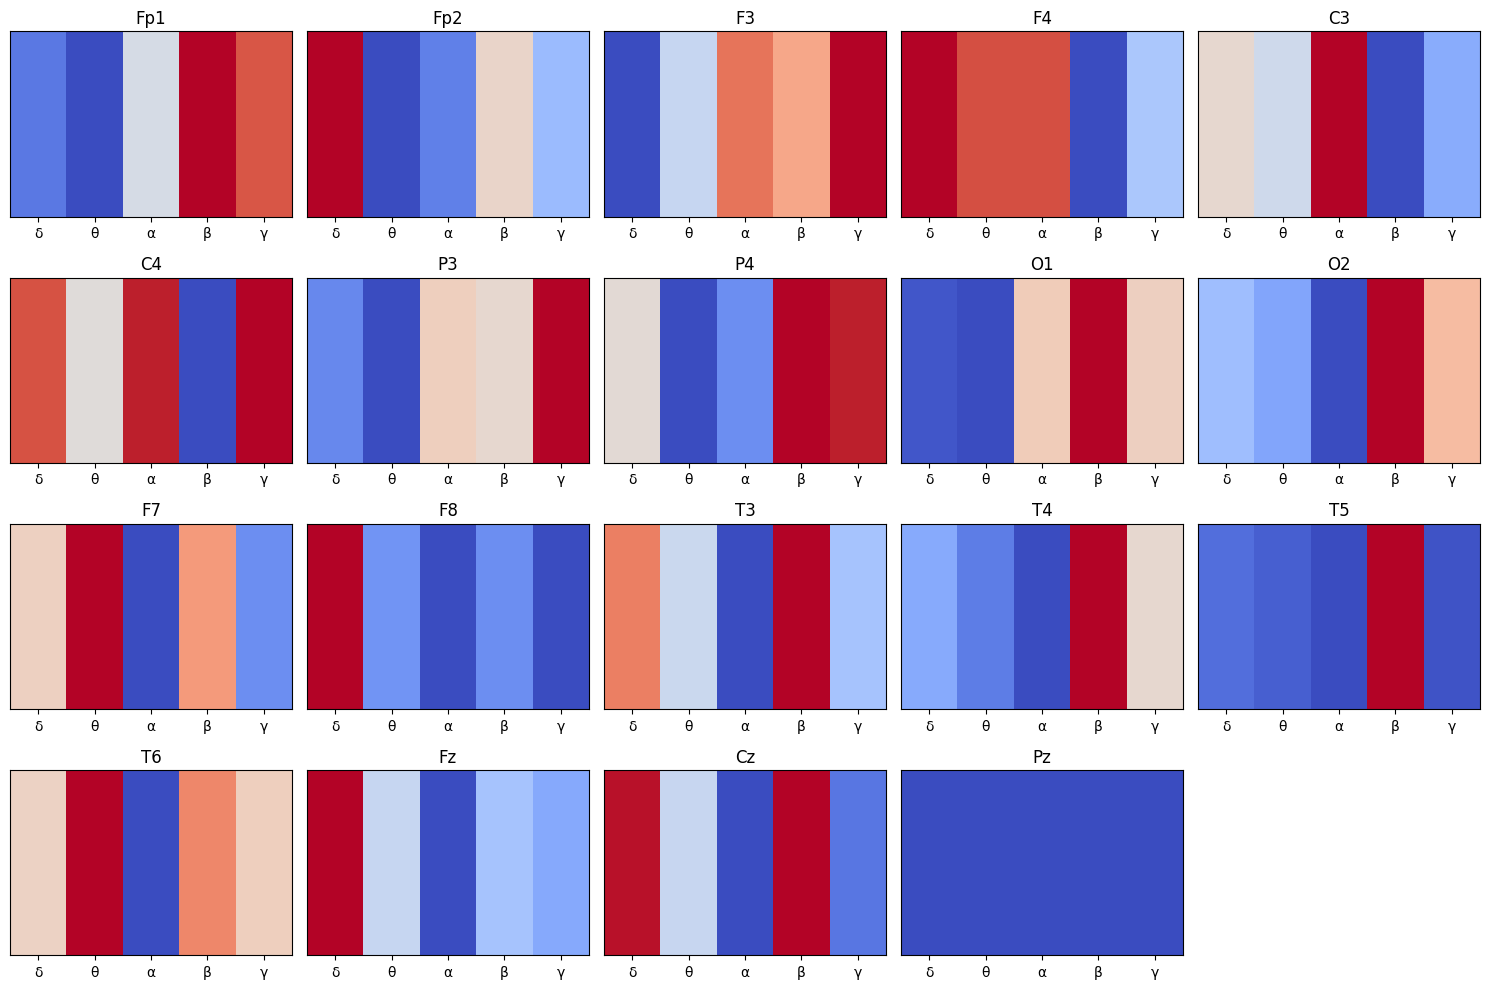

In [38]:
fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].imshow(mean_shap[i].reshape(1,5), 
                   cmap='coolwarm', 
                   aspect='auto')
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].set_yticks([])
# Hide unused subplot
axes[19].axis('off')
plt.tight_layout()
plt.show()

##########         MEAN SHAP VALUES FOR Class 0  ############

In [39]:
y_test[2880:2886]

array([0, 0, 0, 0, 0, 0])

In [42]:
import shap
import numpy as np

# Take small random background set
background = X_train[np.random.choice(X_train.shape[0], 1000, replace=False)]

# 2) build explainer
explainer = shap.DeepExplainer(model_1d, background)

# 3) get SHAP values for some test samples
X_sample = X_test[5900:5908]     # (100, 19, 33, 6, 1)
shap_values = explainer.shap_values(X_sample)  # list; for binary: len=1
sh = shap_values

f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(8, 19, 5))']
  warnings.warn(msg)


In [43]:
shap_values.shape
sh.shape

(8, 19, 5, 2)

In [44]:
shap_class1 = shap_values[:, :, :, 1]
shap_class0 = shap_values[:, :, :, 0]

print(shap_class0.shape)

(8, 19, 5)


In [47]:
mean_shap_class0 = np.mean(shap_class0, axis=0)   # (19, 5)

mean_shap_class0.shape

(19, 5)

############      Electrode-wise Band Explanation (Like Fp1, Fp2 blocks)          #########

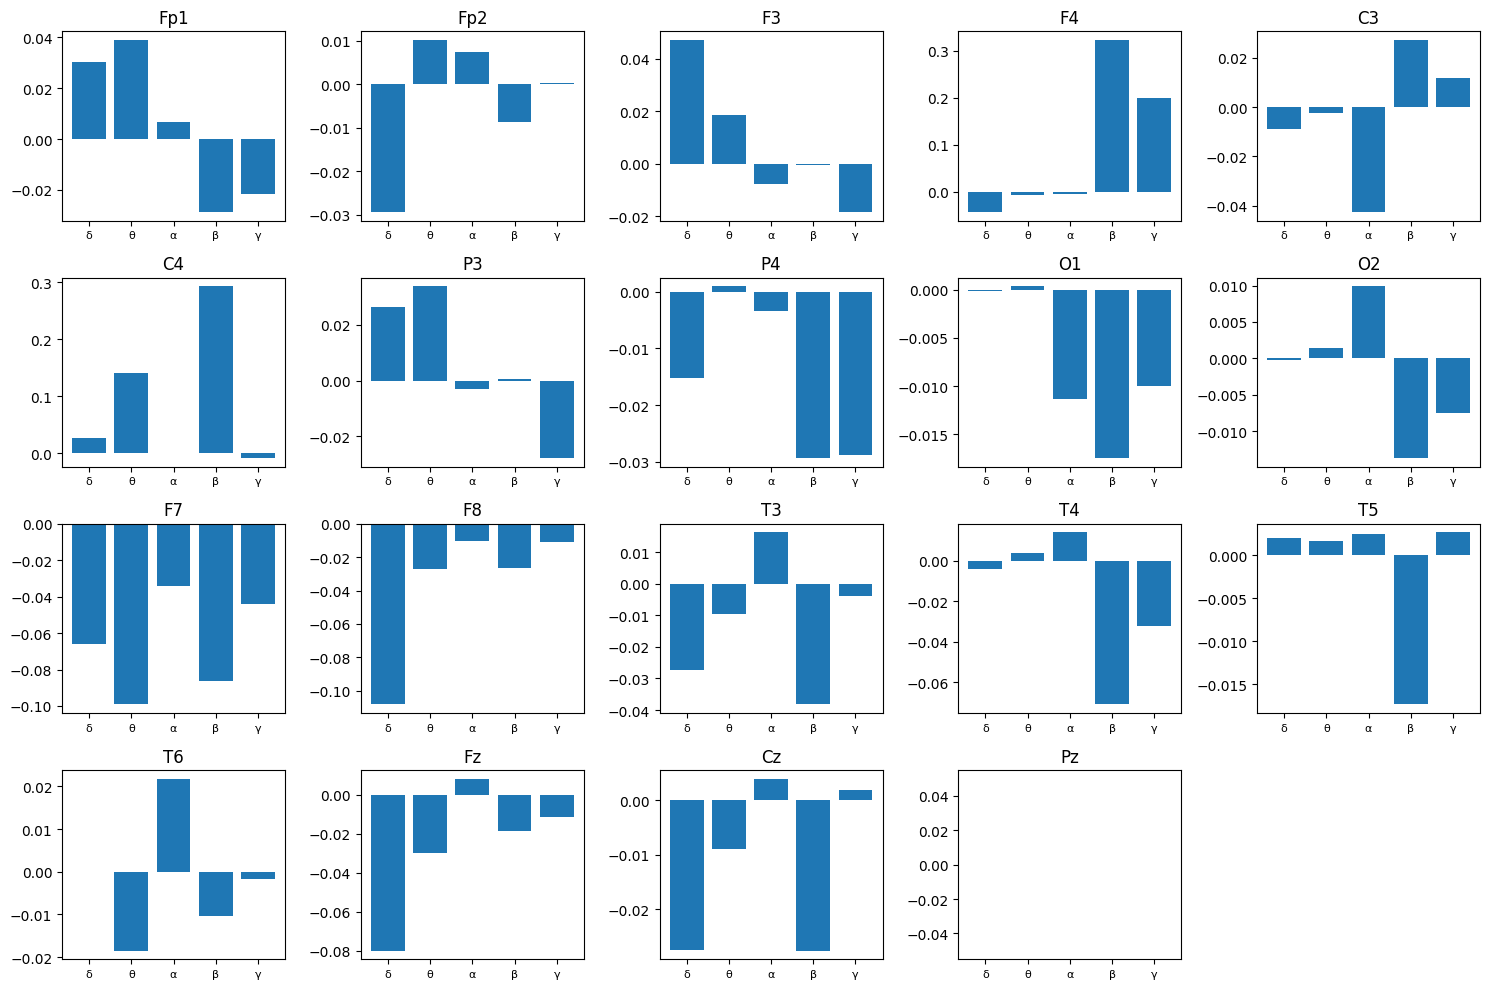

In [48]:
import matplotlib.pyplot as plt
import numpy as np

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].bar(range(5), mean_shap_class0[i])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].tick_params(axis='x', labelsize=8)
axes[19].axis('off')
plt.tight_layout()
plt.show()

#############    Mini Heatmap Per Electrode          ###############

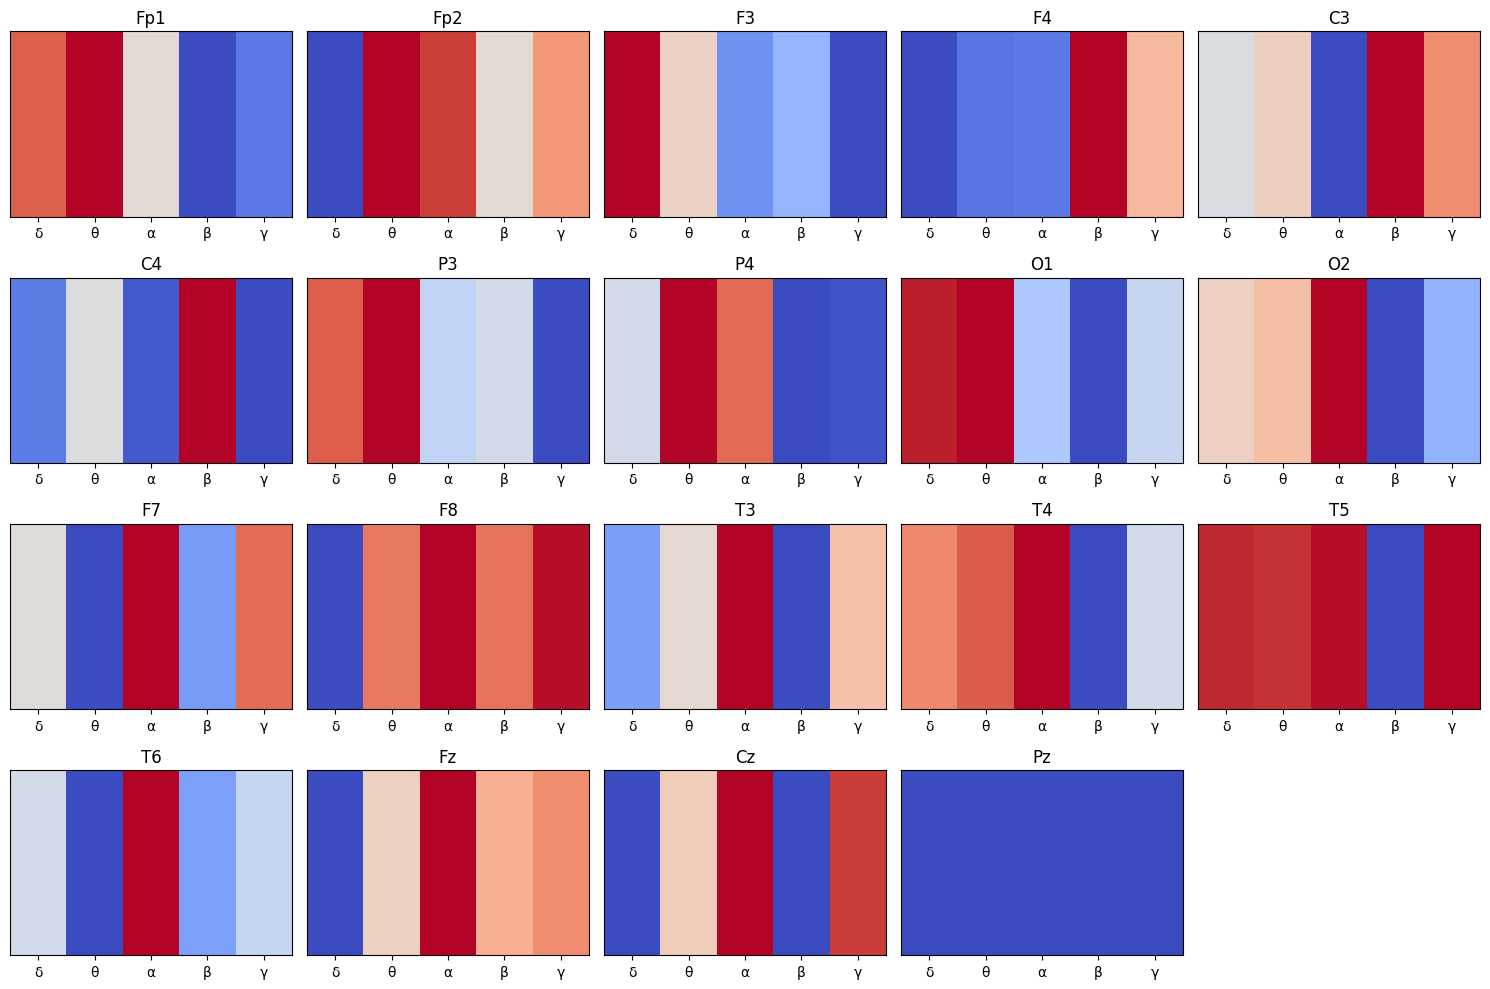

In [49]:
fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].imshow(mean_shap_class0[i].reshape(1,5), 
                   cmap='coolwarm', 
                   aspect='auto')
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].set_yticks([])
# Hide unused subplot
axes[19].axis('off')
plt.tight_layout()
plt.show()

######################   Train 2D CNN model on EEG Dataset  ############

In [50]:
X_2d = np.expand_dims(X, axis=-1)

print(X_2d.shape)

(28863, 19, 5, 1)


In [51]:
import numpy as np

X = X_2d          # shape (N, ...)
y = y         # shape (N,)
N = len(y)

rng = np.random.default_rng(seed=42)

train_idx = []
val_idx   = []
test_idx  = []

for cls in np.unique(y):
    cls_idx = np.where(y == cls)[0]
    rng.shuffle(cls_idx)

    n_cls   = len(cls_idx)
    n_train = int(0.70 * n_cls)
    n_val   = int(0.20 * n_cls)

    train_idx.extend(cls_idx[:n_train])
    val_idx.extend(cls_idx[n_train:n_train + n_val])
    test_idx.extend(cls_idx[n_train + n_val:])

train_idx = np.array(train_idx)
val_idx   = np.array(val_idx)
test_idx  = np.array(test_idx)

X_train_2d, y_train_2d = X[train_idx], y[train_idx]
X_val_2d,   y_val_2d   = X[val_idx],   y[val_idx]
X_test_2d,  y_test_2d  = X[test_idx],  y[test_idx]


In [55]:
# Compute mean & std from training set only
mean = X_train_2d.mean(axis=(0), keepdims=True)
std  = X_train_2d.std(axis=(0), keepdims=True)

# Apply normalization
X_train_2d = (X_train_2d - mean) / (std + 1e-8)
X_val_2d   = (X_val_2d   - mean) / (std + 1e-8)
X_test_2d  = (X_test_2d  - mean) / (std + 1e-8)

In [79]:
print(X_train_2d.shape, y_train_2d.shape)
print(X_val_2d.shape, y_val_2d.shape)
print(X_test_2d.shape, y_test_2d.shape)

(20204, 19, 5, 1) (20204,)
(5772, 19, 5, 1) (5772,)
(2887, 19, 5, 1) (2887,)


In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Define Input
inputs = Input(shape=(19, 5, 1))

# Convolution Block 1
x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = MaxPooling2D(pool_size=(2,2))(x)

# Convolution Block 2
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Flatten
x = Flatten()(x)

# Fully Connected
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)

# Output Layer (2 classes)
outputs = Dense(2, activation='softmax')(x)

# Create Model
model_2d = Model(inputs=inputs, outputs=outputs)

# Compile
model_2d.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2d.summary()

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 19, 5, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 5, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 9, 2, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,394 (138.26 KB)

 Trainable params: 35,394 (138.26 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
history = model_2d.fit(
    X_train_2d, y_train_2d,
    validation_data=(X_val_2d, y_val_2d),
    epochs=50,
    batch_size=32
)

Epoch 1/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5485 - loss: 0.6889 - val_accuracy: 0.5485 - val_loss: 0.6882
Epoch 2/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5485 - loss: 0.6885 - val_accuracy: 0.5485 - val_loss: 0.6880
Epoch 3/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5486 - loss: 0.6885 - val_accuracy: 0.5485 - val_loss: 0.6880
Epoch 4/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5481 - loss: 0.6883 - val_accuracy: 0.5483 - val_loss: 0.6887
Epoch 5/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5475 - loss: 0.6884 - val_accuracy: 0.5489 - val_loss: 0.6876
Epoch 6/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5487 - loss: 0.6883 - val_accuracy: 0.5487 - val_loss: 0.6874
Epoch 7/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5488 - loss: 0.6878 - val_accuracy: 0.5492 - val_loss: 0.6871
Epoch 8/50
632/632 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5489 - loss: 0.6876 - val_accuracy: 0.

In [91]:
model_2d.save(r"D:\EEG DATA\eeg_model_2d.h5")

In [92]:
model_2d.evaluate(X_test_2d, y_test_2d)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8150 - loss: 1.6891


[1.689113974571228, 0.8150328993797302]

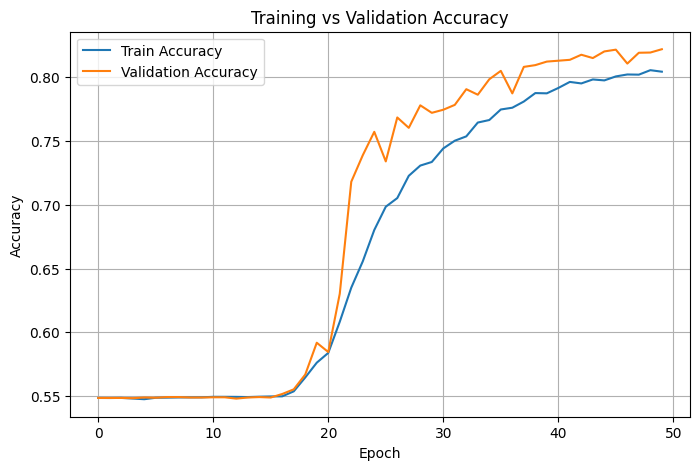

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

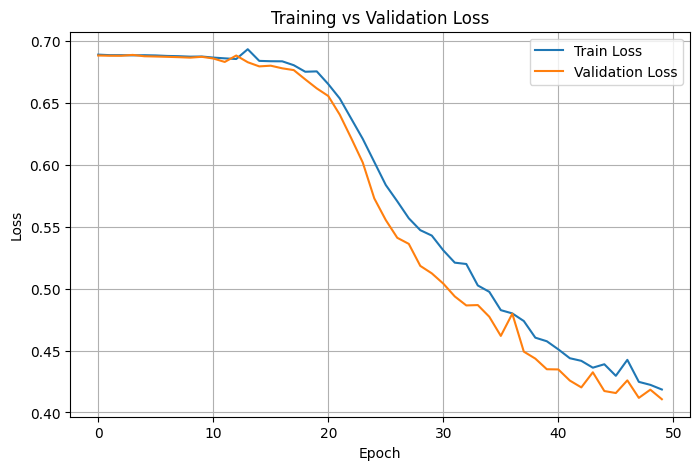

In [94]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [95]:
import numpy as np

# Train probabilities
y_train_prob = model_2d.predict(X_train_2d)[:, 1]

# Test probabilities
y_test_prob = model_2d.predict(X_test_2d)[:, 1]

632/632 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [96]:
from sklearn.metrics import roc_curve, auc

# Train ROC
fpr_train, tpr_train, _ = roc_curve(y_train_2d, y_train_prob)
auc_train = auc(fpr_train, tpr_train)

# Test ROC
fpr_test, tpr_test, _ = roc_curve(y_test_2d, y_test_prob)
auc_test = auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

Train AUC: 0.9085680439970532
Test AUC: 0.8995165585246168


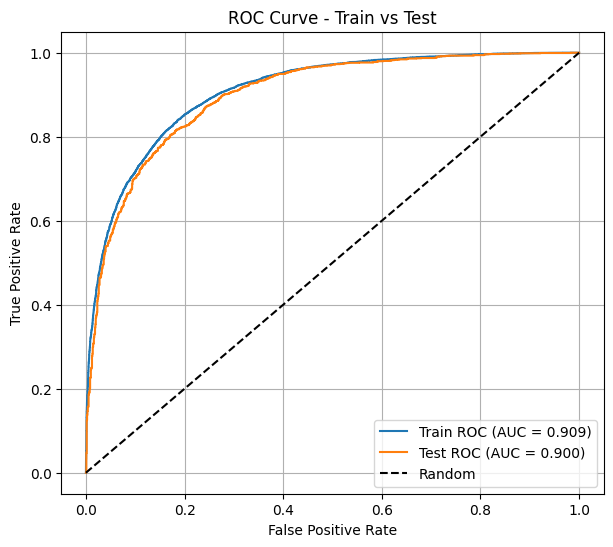

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {auc_train:.3f})')
plt.plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {auc_test:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Train vs Test')
plt.legend()
plt.grid(True)

plt.show()



In [98]:
# predicted class probabilities from softmax
y_prob_all = model_2d.predict(X_test_2d)          # shape (n_samples, 2)

# choose prob for class 1 (seizure)
y_prob = y_prob_all[:, 1]

# class predictions
y_pred = np.argmax(y_prob_all, axis=1)      # 0 or 1

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [99]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, roc_auc_score
)

acc   = accuracy_score(y_test_2d, y_pred)
prec  = precision_score(y_test_2d, y_pred)
sens  = recall_score(y_test_2d, y_pred)        # sensitivity = recall for positive class
cm    = confusion_matrix(y_test_2d, y_pred)
tn, fp, fn, tp = cm.ravel()
spec  = tn / (tn + fp)                      # specificity
f1    = f1_score(y_test_2d, y_pred)
kappa = cohen_kappa_score(y_test_2d, y_pred)
auc   = roc_auc_score(y_test_2d, y_prob)
err   = 1 - acc

print("Accuracy:", acc)
print("Error:", err)
print("Precision:", prec)
print("Sensitivity (Recall):", sens)
print("Specificity:", spec)
print("F1-score:", f1)
print("Kappa:", kappa)
print("AUC:", auc)
print("Confusion matrix:\n", cm)


Accuracy: 0.8150329061309317
Error: 0.1849670938690683
Precision: 0.8382731958762887
Sensitivity (Recall): 0.8213383838383839
Specificity: 0.807367613200307
F1-score: 0.829719387755102
Kappa: 0.6273394351707173
AUC: 0.8995165585246168
Confusion matrix:
 [[1052  251]
 [ 283 1301]]


#############   SHAP Explainer             #############

In [100]:
print(X_train_2d.shape)

(20204, 19, 5, 1)


In [101]:
_ = model_2d(X_train_2d[:1])

In [102]:
import shap
import numpy as np

background = X_train_2d[np.random.choice(X_train_2d.shape[0], 1000, replace=False)]

explainer = shap.GradientExplainer(
    (model_2d.input, model_2d.output),
    background
)

In [103]:
X_sample = X_test_2d[2880:2887]
X_sample.shape


(7, 19, 5, 1)

In [114]:
shap_values = explainer.shap_values(X_sample)  # list; for binary: len=1
sh = shap_values


f:\Anaconda\envs\new_env\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_120
Received: inputs=['Tensor(shape=(7, 19, 5, 1))']
  warnings.warn(msg)


In [118]:
shap_class1 = shap_values[..., 1]
print(shap_class1.shape)

(7, 19, 5, 1)


In [119]:
shap_class1 = shap_class1.squeeze(-1)
print(shap_class1.shape)

(7, 19, 5)


In [147]:
mean_shap = np.mean(shap_class1, axis=0)

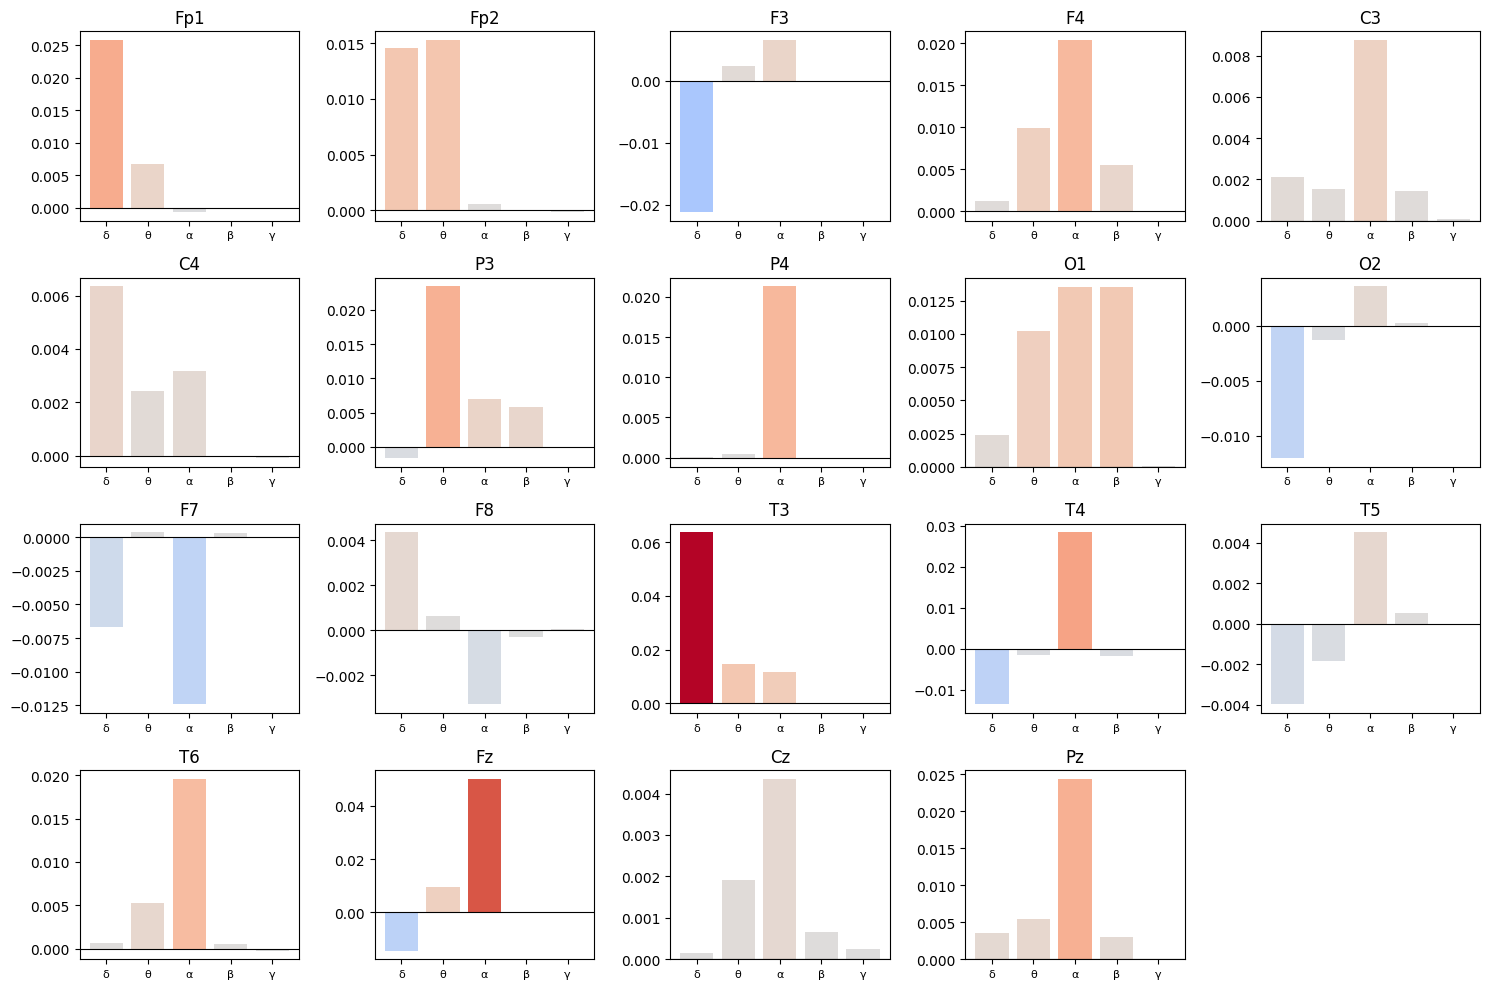

In [148]:
import matplotlib.cm as cm

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

band_names = ['δ','θ','α','β','γ']

fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

vmax = np.max(np.abs(mean_shap))
norm = plt.Normalize(vmin=-vmax, vmax=vmax)

for i in range(19):

    values = mean_shap[i]
    colors = cm.coolwarm(norm(values))

    axes[i].bar(range(5), values, color=colors)
    axes[i].axhline(0, color='black', linewidth=0.8)

    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(band_names)
    axes[i].tick_params(axis='x', labelsize=8)

axes[19].axis('off')

plt.tight_layout()
plt.show()

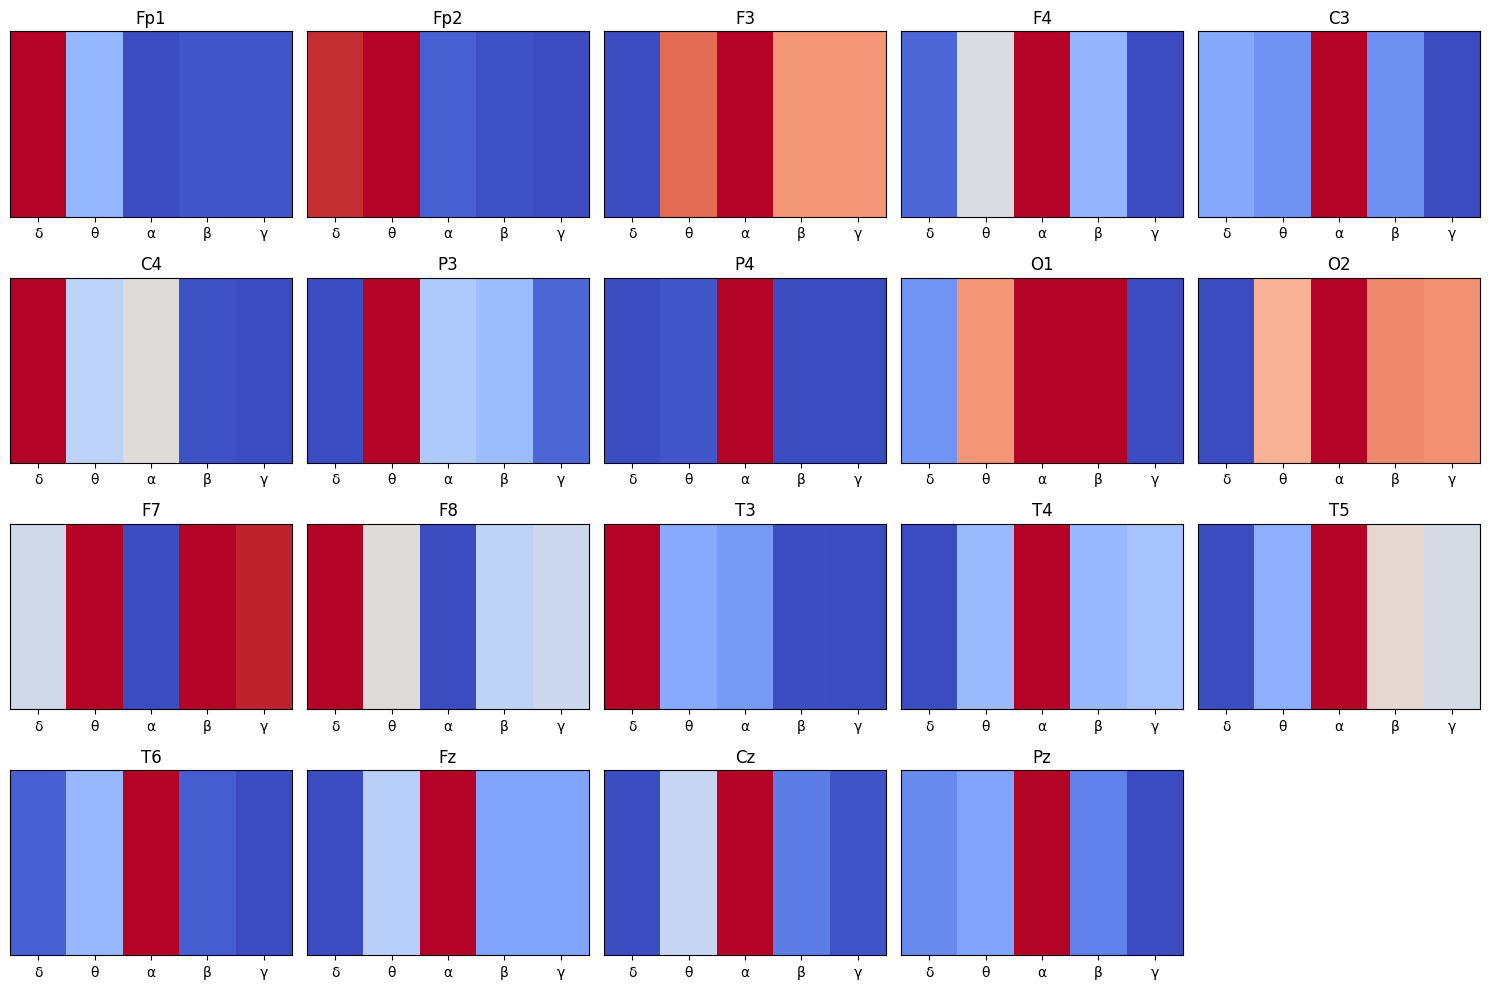

In [149]:
fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].imshow(mean_shap[i].reshape(1,5), 
                   cmap='coolwarm', 
                   aspect='auto')
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].set_yticks([])
# Hide unused subplot
axes[19].axis('off')
plt.tight_layout()
plt.show()

##############       SHAP VALUES for 2D CNN CLASS 0        #######

In [150]:
shap_class0 = shap_values[..., 0]
print(shap_class0.shape)

(7, 19, 5, 1)


In [144]:
shap_class0 = shap_class0.squeeze(-1)
print(shap_class0.shape)

(7, 19, 5)


In [145]:
mean_shap_class0 = np.mean(shap_class0, axis=0)   # (19, 5)

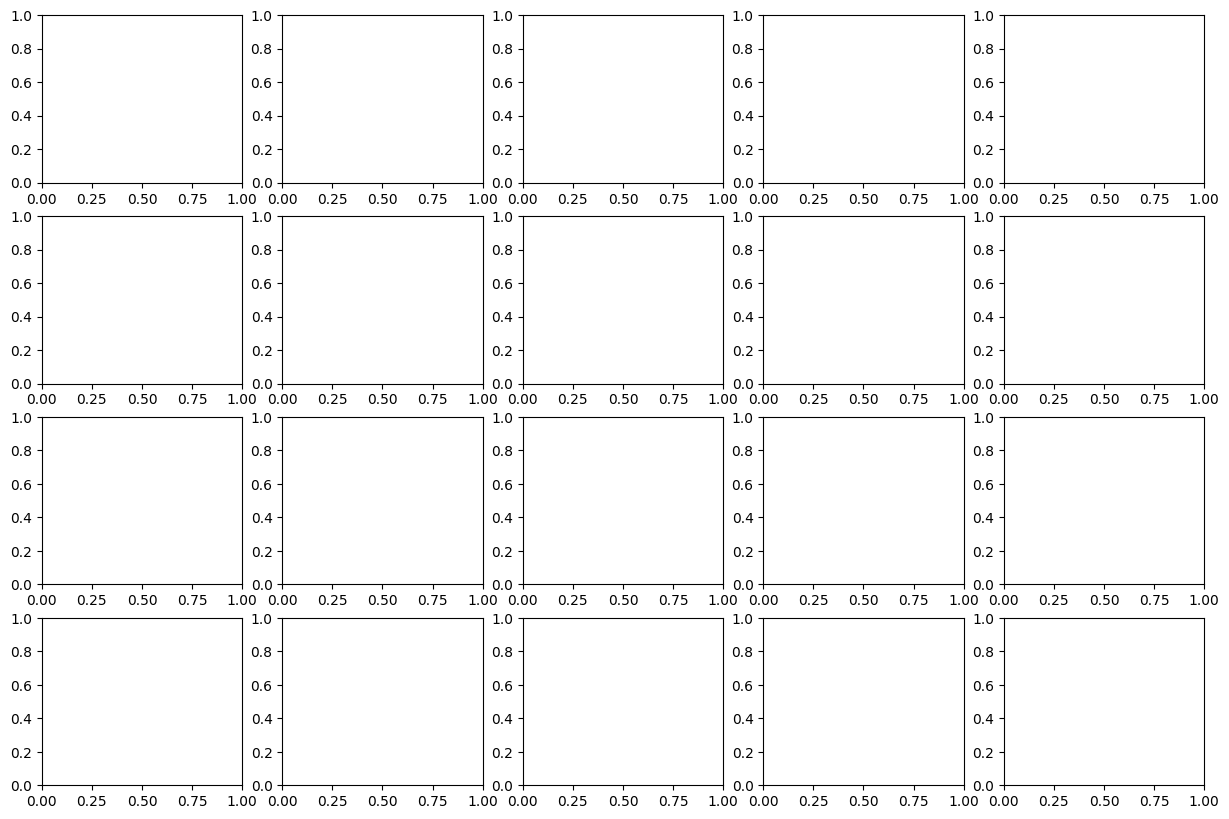

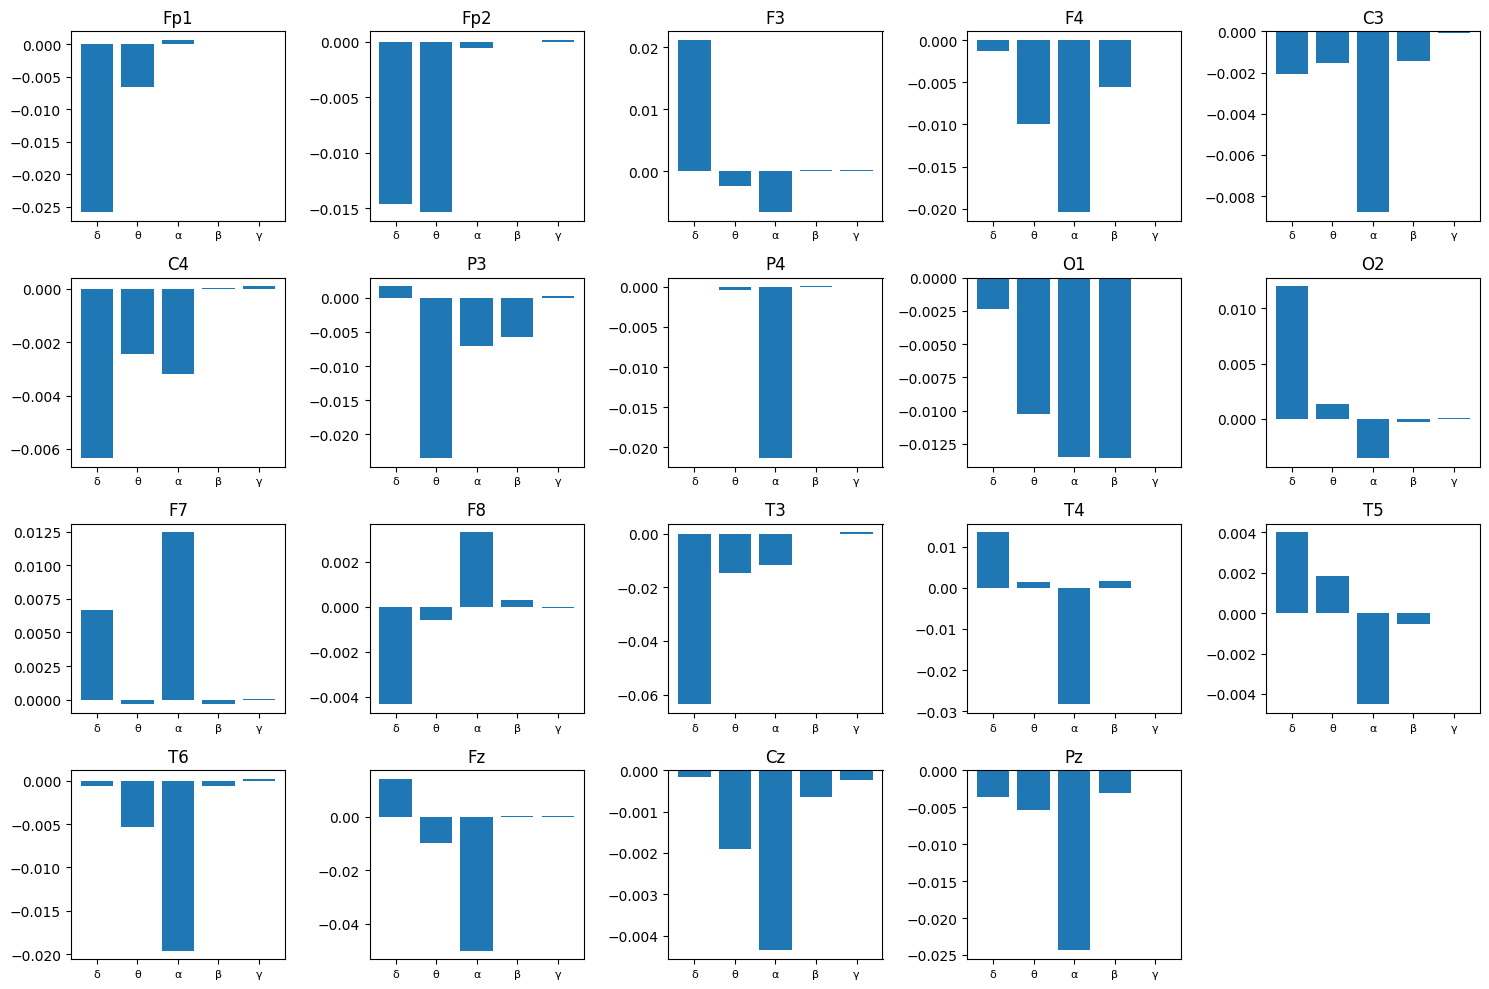

In [151]:
import matplotlib.cm as cm

electrode_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4',
    'O1','O2','F7','F8','T3','T4','T5','T6',
    'Fz','Cz','Pz'
]

band_names = ['δ','θ','α','β','γ']


fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

vmax = np.max(np.abs(mean_shap_class0))
norm = plt.Normalize(vmin=-vmax, vmax=vmax)
fig, axes = plt.subplots(4, 5, figsize=(15,10))
axes = axes.flatten()

for i in range(19):
    axes[i].bar(range(5), mean_shap_class0[i])
    axes[i].set_title(electrode_names[i])
    axes[i].set_xticks(range(5))
    axes[i].set_xticklabels(['δ','θ','α','β','γ'])
    axes[i].tick_params(axis='x', labelsize=8)
axes[19].axis('off')
plt.tight_layout()
plt.show()